
**-----PROJEKT--GRUPP6-----** <br>
Pär Hedström<br>
Fredrik Domert Eriksson<br>
Rickard Andersson<br>

**Data Collection Spider**<br>
Jag har gjort ett försök till att bygga en Spider som utför Web Scraping. Den simulerar en mänsklig användare för att hämta strukturerad data från en databas. Eller i det här fallet en webbsida. Jag har byggt den ganska generellt just med filter-valen, det kan vi ju ändra lite som vi vill sen när vi är överens. Men den fungerar bra. Den laddar ner en csv-fil i en mapp (data_folder) som skapas i den mapp där jupyter-filen ligger. När man kör koden så kommer hemsidan upp och sen tar det kanske 10 sek innan den skriver i sökfältet. /RA

In [3]:
# Använt kod från https://www.geeksforgeeks.org/web-scraping/scrape-linkedin-using-selenium-and-beautiful-soup-in-python/

# Installerar selenium för att kunna hantera knappar och menyer
%pip install selenium

Note: you may need to restart the kernel to use updated packages.


In [4]:
# Importerar dom bibliotek vi behöver

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import Select
import time
import os

# --- KONFIGURATION & SÖKVÄGAR ---
SEARCH_TERM = "Avsiktligt självdestruktiv handling"
DATA_DIR = os.path.join(os.getcwd(), "data_folder")

# Skapar en mapp om den inte redan finns
if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR)

chrome_options = Options()
chrome_options.add_experimental_option("prefs", {
    "download.default_directory": DATA_DIR,
    "download.prompt_for_download": False,
    "download.directory_upgrade": True,
    "safebrowsing.enabled": True
})

driver = webdriver.Chrome(options=chrome_options)
wait = WebDriverWait(driver, 20)

# Här startas sidan (socialstyrelsen) där man kan välja filter och använda sökfältet 
try:
    print(f"Startar sökning. Filer kommer sparas i: {DATA_DIR}")
    driver.get("https://sdb.socialstyrelsen.se/if_dor/val.aspx")

    print("Väljer månadsuppgifter...")
    # Det första vi vill göra är att välja månadsuppgifter då det ändrar filtreringen
    try:
        # Vi letar efter select-elementet inuti diven
        select_ar_manad = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "div[id*='armanad_ind'] select"))) # Div-element för År/månadsuppgifter
        s_typer = Select(select_ar_manad)
        s_typer.select_by_visible_text("Månadsuppgifter")
        
        # Trigga sidans eget skript för att rita om gränssnittet till månadsvisning
        driver.execute_script("arguments[0].onchange();", select_ar_manad)
    except Exception as e:
        # Om select-logiken inte fungerar
        print("Kör reservmetod för månadsuppgifter...")
        driver.execute_script("document.querySelector(\"div[id*='armanad_ind'] select\").value = 'm';")
    time.sleep(2.5)

    # Om det ligger gamla val eller text i sökfält så rensas det
    print("Nollställer tidigare val...")
    try:
        rensa = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_dia_id_btnRensaValda"))) # html-element för rensning av val
        driver.execute_script("arguments[0].click();", rensa)
    except:
        pass

    # Använder sökfältet
    print(f"Söker efter: '{SEARCH_TERM}'...")
    sok_falt = wait.until(EC.element_to_be_clickable((By.ID, "Sokord"))) # html-element för sökfält
    sok_falt.clear()
    sok_falt.send_keys(SEARCH_TERM)
    sok_falt.send_keys(Keys.ENTER)

    # Bockar i rutor för sökresultat
    # Har lagt ut några print då det krånglade en del så jag kunde se vart det tog stopp
    print("Markerar diagnosrutor...")
    wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']"))) # html-element för checkbox sök-resultat
    checkboxar = driver.find_elements(By.CSS_SELECTOR, "#sokListaArea input[type='checkbox']")
    for cb in checkboxar:
        if not cb.is_selected():
            driver.execute_script("arguments[0].click();", cb)
    
    # Filter för Ålder, Kön och månad där vi bockar i Välj alla
    print("Väljer filter...")
    time.sleep(1)
    knappar_att_klicka = [
        "ph1_val_kon_id_hlAdd",    # Välj alla för Kön
        "ph1_val_ar_id_hlAdd",     # Välj alla för År
        "ph1_val_manad_id_hlAdd"   # Välj alla för Månad
    ]
    
    for knap_id in knappar_att_klicka:
        try:
            knapp = driver.find_element(By.ID, knap_id)
            driver.execute_script("arguments[0].click();", knapp)
            time.sleep(0.1)
        except Exception as e:
            print(f"Kunde inte klicka på filter {knap_id}: {e}")

    # Letar upp knappen för Visa resultat
    # Generera tabell och hämta CSV
    print("Genererar tabell...")
    try:
        # Kör javascript-funktionen direkt
        driver.execute_script("submitResultat();")
    except:
        # Backup om JS-anropet krånglar
        visa_lank = wait.until(EC.element_to_be_clickable((By.ID, "ph1_val_data_id_lnkVisaResultat"))) # html-element
        driver.execute_script("arguments[0].click();", visa_lank)

    # Nu har vi kommit till resultat-sidan av vår sökning.
    # Högst upp till höger letar vi på csv-länken som laddar ner filen till vår mapp.
    print("Hämtar CSV-fil...")
    csv_knapp = wait.until(EC.element_to_be_clickable((By.CSS_SELECTOR, "a[id$='lbCSV']")))
    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", csv_knapp)
    time.sleep(0.5)
    csv_knapp.click()
    
    print(f"KLART! Din data ligger nu i din mapp.")
    time.sleep(2) # Tid för Chrome då det gick lite för fort tidigare

except Exception as e:
    print(f"Ett fel uppstod: {e}")

# Stänger ner sidan när allt är klart
finally:
    # Vi kollar om driver existerar innan vi försöker stänga den
    if 'driver' in locals() or 'driver' in globals():
        try:
            driver.close() # Stänger fliken
            driver.quit()  # Stänger hela programmet
            print("Webbläsaren stängdes korrekt.")
        except:
            pass # Om den redan var stängd gör vi ingenting

Startar sökning. Filer kommer sparas i: c:\Users\Lenovo\Desktop\Högskolan Dalarna\Projekt - ML -Grupp 6\projekt-grupp6\data_folder
Väljer månadsuppgifter...
Kör reservmetod för månadsuppgifter...
Nollställer tidigare val...
Söker efter: 'Avsiktligt självdestruktiv handling'...
Markerar diagnosrutor...
Väljer filter...
Genererar tabell...
Hämtar CSV-fil...
KLART! Din data ligger nu i din mapp.
Webbläsaren stängdes korrekt.


**Data-Analys**

**Visualisering**

In [6]:
import pandas as pd
import numpy as np

# 1. Ladda in datan
# skiprows=1 hoppar över den allra översta raden med metadata, 
# så att raden med "Kön;Januari 1997..." blir våra faktiska kolumnnamn.
file_path = 'data_folder/Statistikdatabasen_2026-05-19 13_05_32.csv'
df = pd.read_csv(file_path, sep=';', skiprows=1)

# 2. Rensa bort texten i botten
# Vi behåller bara de tre raderna som faktiskt innehåller könen.
df = df[df['Kön'].isin(['Män', 'Kvinnor', 'Båda könen'])]

# 3. Magin: Omforma datan från Bred till Lång (Melt)
# Detta tar alla hundratals månadskolumner och lägger dem i en enda kolumn som heter 'Tid'.
df_long = pd.melt(df, id_vars=['Kön'], var_name='Tid', value_name='Antal')

# 4. Städa bort saknad data
# Socialstyrelsen använder ibland '­­' för månader som inte har data än (ex slutet av 2026)
# Vi gör om dessa till "Not a Number" (NaN) och droppar dem, samt ser till att antalet är siffror.
df_long['Antal'] = pd.to_numeric(df_long['Antal'].replace('­­', np.nan), errors='coerce')
df_long = df_long.dropna(subset=['Antal'])

# 5. Den nya uppdaterade ordlistan för hela månadsnamn
month_map = {
    'Januari': '01', 'Februari': '02', 'Mars': '03', 'April': '04',
    'Maj': '05', 'Juni': '06', 'Juli': '07', 'Augusti': '08',
    'September': '09', 'Oktober': '10', 'November': '11', 'December': '12'
}

# 6. Översätt månaderna (t.ex. görs "Januari 1997" om till "01 1997")
for swe_month, num_month in month_map.items():
    df_long['Tid'] = df_long['Tid'].str.replace(swe_month, num_month)

# ... (allt innan steg 7 är exakt som förut)

# 7. Konvertera texten till Pandas-datum (skapar först 1997-01-01 internt)
df_long['Datum'] = pd.to_datetime(df_long['Tid'], format='%m %Y')

# 8. Sätt datumet som Index
df_long.set_index('Datum', inplace=True)

# NYTT TILLÄGG: Gör om indexet från "Exakt dag" till "Månadsperiod" (t.ex. 1997-01)
df_long.index = df_long.index.to_period('M')

# Sortera kronologiskt
df_long = df_long.sort_index()

# Titta på resultatet
display(df_long.head())

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21588\2538553814.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_long['Antal'] = pd.to_numeric(df_long['Antal'].replace('­­', np.nan), errors='coerce')


,Kön,Tid,Antal
Datum,,,
1997-01,Män,01 1997,82.0
1997-01,Kvinnor,01 1997,22.0
1997-01,Båda könen,01 1997,104.0
1997-02,Män,02 1997,70.0
1997-02,Kvinnor,02 1997,29.0


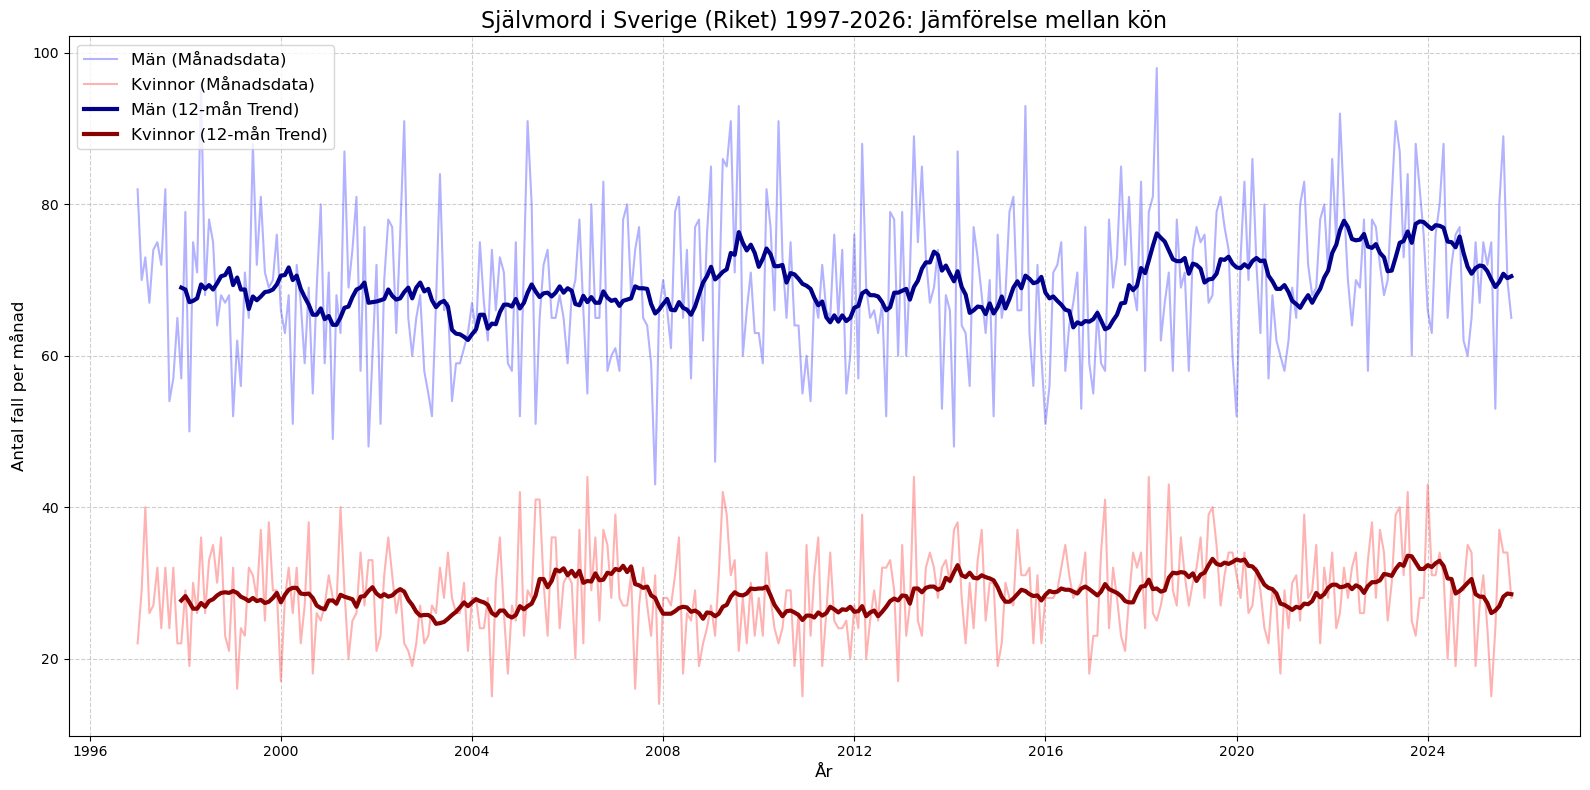

In [7]:
import matplotlib.pyplot as plt

# 1. Filtrera ut datan för Män respektive Kvinnor
df_men = df_long[df_long['Kön'] == 'Män'].copy()
df_women = df_long[df_long['Kön'] == 'Kvinnor'].copy()

# 2. Beräkna ett 12-månaders rullande medelvärde för att se trenden tydligare
df_men['Trend_12m'] = df_men['Antal'].rolling(window=12).mean()
df_women['Trend_12m'] = df_women['Antal'].rolling(window=12).mean()

# 3. Bygg upp grafen
plt.figure(figsize=(16, 8))

# Plotta den hoppiga månadsdatan lite transparent i bakgrunden (alpha=0.3)
plt.plot(df_men.index.to_timestamp(), df_men['Antal'], color='blue', alpha=0.3, label='Män (Månadsdata)')
plt.plot(df_women.index.to_timestamp(), df_women['Antal'], color='red', alpha=0.3, label='Kvinnor (Månadsdata)')

# Plotta de tydliga trendlinjerna starkare ovanpå
plt.plot(df_men.index.to_timestamp(), df_men['Trend_12m'], color='darkblue', linewidth=3, label='Män (12-mån Trend)')
plt.plot(df_women.index.to_timestamp(), df_women['Trend_12m'], color='darkred', linewidth=3, label='Kvinnor (12-mån Trend)')

# Formatering av grafen
plt.title('Självmord i Sverige (Riket) 1997-2026: Jämförelse mellan kön', fontsize=16)
plt.xlabel('År', fontsize=12)
plt.ylabel('Antal fall per månad', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()

# Visa grafen
plt.show()

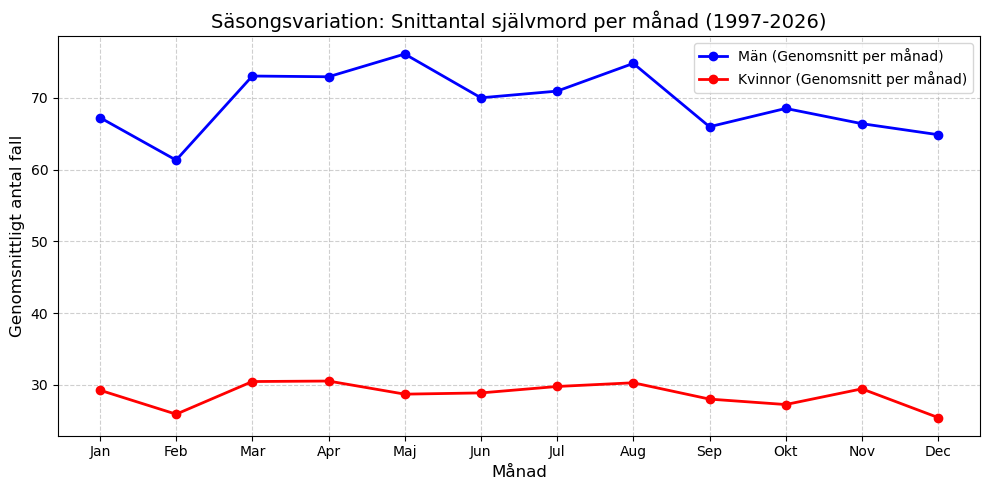

In [11]:
import matplotlib.pyplot as plt

# 1. Skapa en ny kolumn som bara innehåller månadens siffra (1-12)
df_long['Månad_Nr'] = df_long.index.month

# 2. Filtrera för könen
df_men = df_long[df_long['Kön'] == 'Män']
df_women = df_long[df_long['Kön'] == 'Kvinnor']

# 3. Gruppera per månad (1-12) och räkna ut genomsnittet över alla år
monthly_avg_men = df_men.groupby('Månad_Nr')['Antal'].mean()
monthly_avg_women = df_women.groupby('Månad_Nr')['Antal'].mean()

# 4. Bygg upp grafen
plt.figure(figsize=(10, 5))

# Plotta linjerna med små prickar (marker='o') för varje månad
plt.plot(monthly_avg_men.index, monthly_avg_men.values, marker='o', color='blue', linewidth=2, label='Män (Genomsnitt per månad)')
plt.plot(monthly_avg_women.index, monthly_avg_women.values, marker='o', color='red', linewidth=2, label='Kvinnor (Genomsnitt per månad)')

# Formatering av grafen
plt.title('Säsongsvariation: Snittantal självmord per månad (1997-2026)', fontsize=14)
plt.xlabel('Månad', fontsize=12)
plt.ylabel('Genomsnittligt antal fall', fontsize=12)

# Byt ut siffrorna på X-axeln mot riktiga månadsnamn
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'Maj', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec'])

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()

# Visa grafen
plt.show()